In [85]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

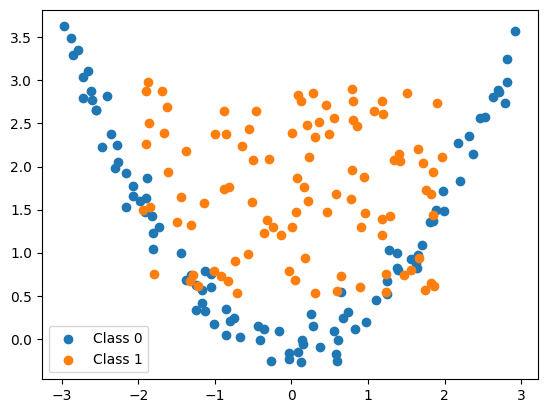

In [88]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100

# Class 0 → U shape
x0 = np.random.uniform(-3, 3, n)

# Parabolic U shape
y0 = 0.4 * x0**2 + np.random.normal(0, 0.2, n)

# Class 1 → points inside/above the U
x1 = np.random.uniform(-2, 2, n)
y1 = np.random.uniform(0.5, 3, n)

# Combine coordinates
X0 = np.column_stack((x0, y0))
X1 = np.column_stack((x1, y1))

# Combine both classes
X = np.vstack((X0, X1))

# Labels
y = np.hstack((
    np.zeros(n),
    np.ones(n)
))

# Plot
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")

plt.legend()
plt.show()

In [106]:
y=np.array(y)

In [91]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [92]:
clf.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<Axes: >

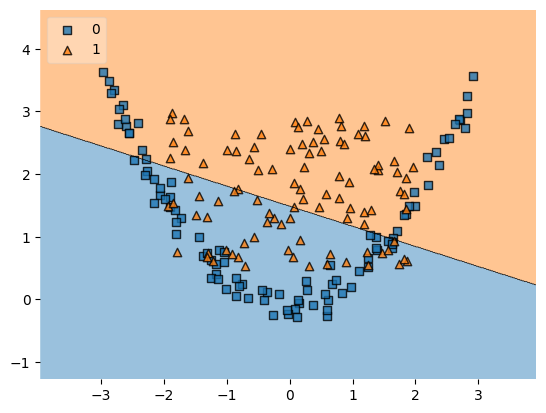

In [109]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype(int), clf, legend=2)

In [110]:
from sklearn.model_selection import cross_val_score

In [114]:
np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10))

0.615

In [115]:
from sklearn.preprocessing import PolynomialFeatures

In [117]:
ploy=PolynomialFeatures(degree=3,include_bias=False)
X_trf=ploy.fit_transform(X)

In [118]:
clf1 = LogisticRegression()
np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

0.86

In [128]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.4)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

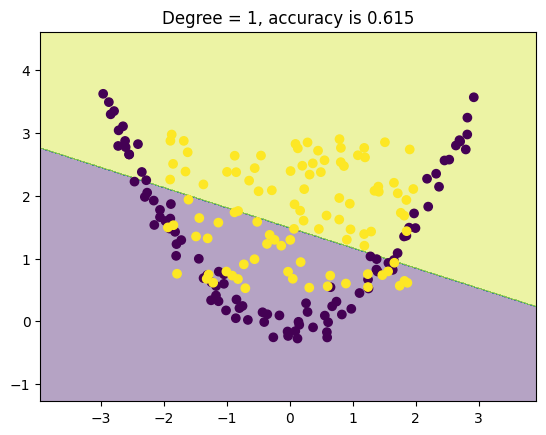

In [129]:
plot_decision_boundary(X,y)

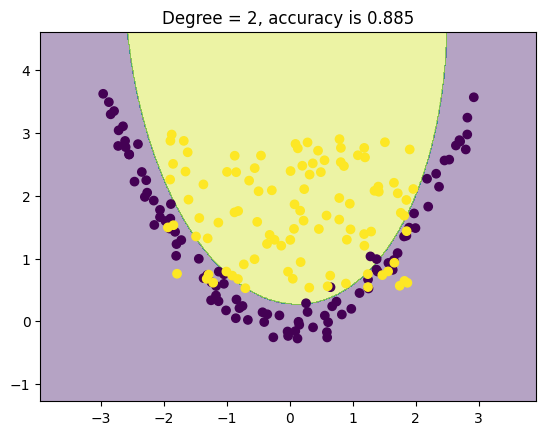

In [130]:
plot_decision_boundary(X,y,degree=2)